# Statistics for Michel electron candidate (28867 full run)

### Created by Shu, 20250417---

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


## Wvf Coincidence Cut (Full run / 5,340 events) (based on Decon wvfs):

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


# Specify the file name
#read data---
noMerge = []
merged = []


with open('./statResult/count_wvfCoin_noMerge.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        noMerge.append(float(currentPlace))
with open('./statResult/count_wvfCoin_merged.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        merged.append(float(currentPlace))


print("Intial event candidates:  5340")
print("Length of noMerge      : ", len(noMerge))
print("Length of merged       : ", len(merged))

#For 5340 candidates:
#noMerge: /Users/shuaixiangzhang/Work/current/FNAL_Work2024/michel_e/t0_tagging/pdhd_DATA_v2/analyze_pdhd_DATA_v2/ \
#         analyze/v2_main/data_src_decon_FullRun/print_wvfCoin.txt; search for "No valid histograms found"
#merged: /Users/shuaixiangzhang/Work/current/FNAL_Work2024/michel_e/t0_tagging/pdhd_DATA_v2/analyze_pdhd_DATA_v2/ \
#        analyze/v2_main/data_src_decon_FullRun/print_wvfCoin_merged.txt; search for "No valid histograms found"
noMerge.extend([0] * 514)
merged.extend([0] * 514)

print("Length of noMerge (+ 514 0s): ", len(noMerge))
print("Length of merged: (+ 514 0s): ", len(merged))



Intial event candidates:  5340
Length of noMerge      :  5694
Length of merged       :  5694
Length of noMerge (+ 514 0s):  6208
Length of merged: (+ 514 0s):  6208



NoMerge (#wvf >= 5):  2696 (50.49%)
Merged  (#wvf >= 5):  2922 (54.72%)


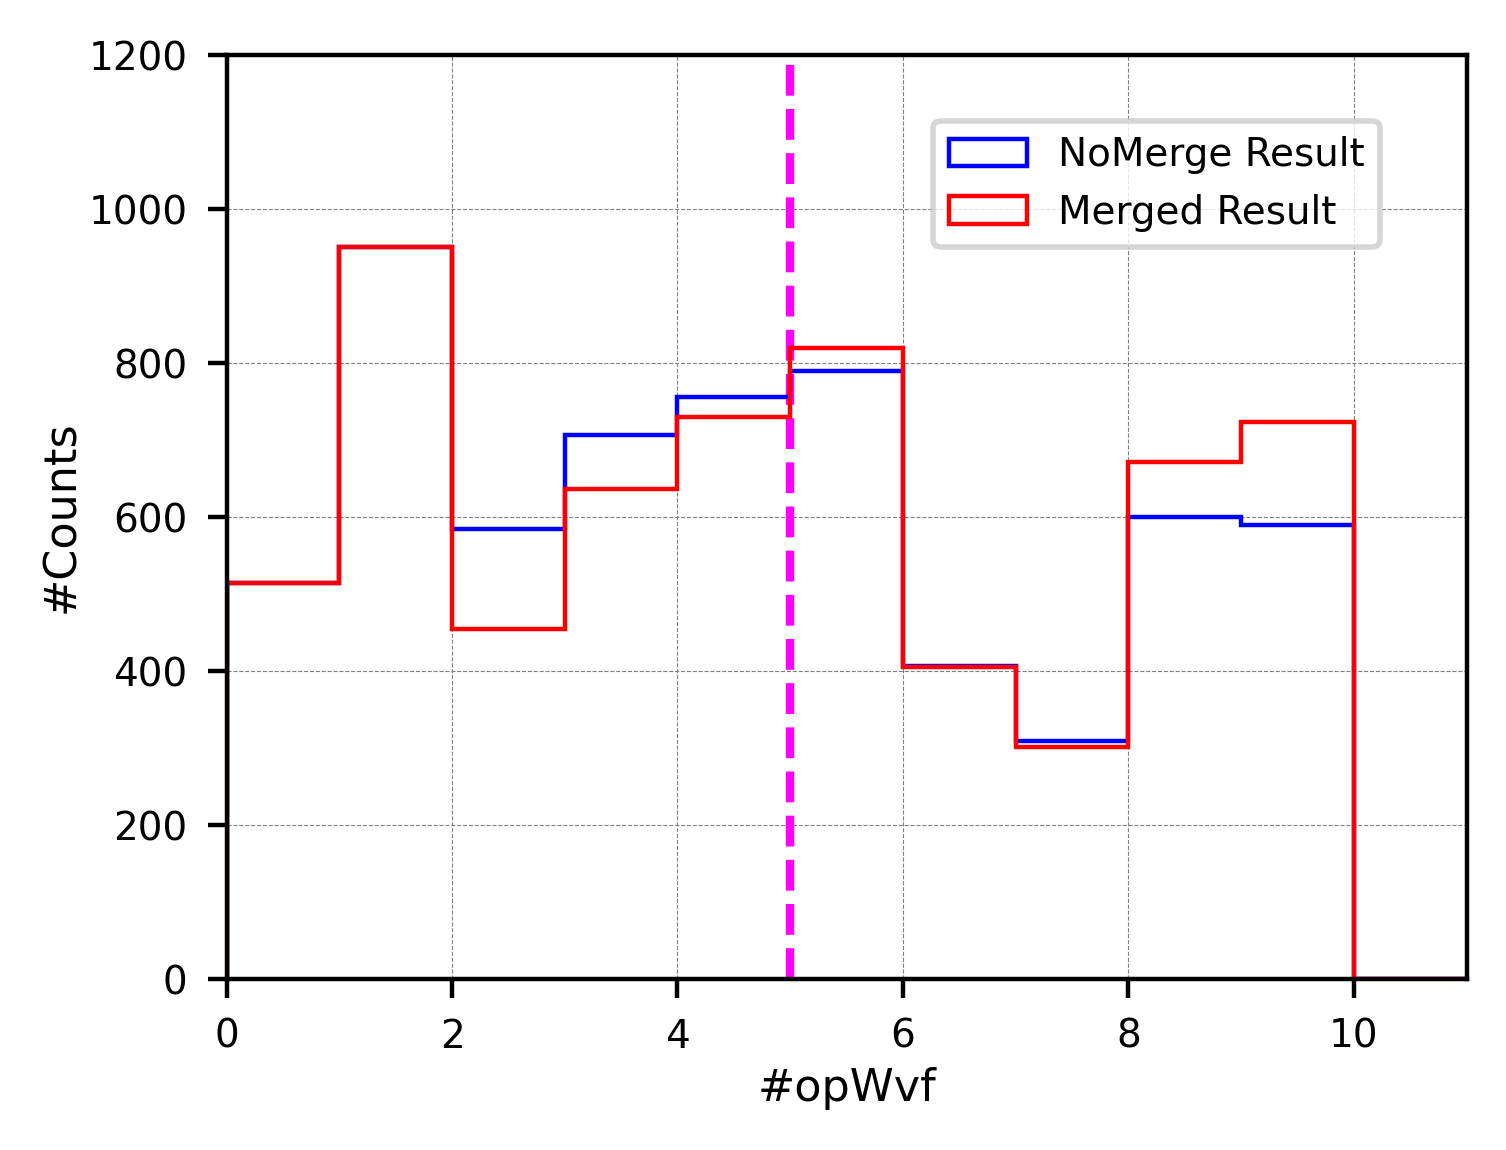

In [2]:
import matplotlib.pyplot as plt
import numpy as np


#Simple statistics------
num_noMerge_ge5 = sum(1 for x in noMerge if x >= 5)
num_merged_ge5 = sum(1 for x in merged if x >= 5)

#Event candidates (after space, MS & MH cuts): # = 1670
print("\nNoMerge (#wvf >= 5): ", num_noMerge_ge5, "({:.2f}%)".format(num_noMerge_ge5/5340*100))
print("Merged  (#wvf >= 5): ", num_merged_ge5, "({:.2f}%)".format(num_merged_ge5/5340*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([5, 5], [0, 1200], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(noMerge, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label='NoMerge Result')
plt.hist(merged, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label='Merged Result')

plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.ylim(0, 1200)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 


<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## PeakFinder (based on merged wvfCoin result):

In [3]:
peakFinder_muTime = []
peakFinder_miTime = []
peakFinder_miCoin = []

# Open the text file and process each line
with open('./statResult/peakFinder_muonTime.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_muTime.append(number)
            except ValueError:
                print(f"Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/peakFinder_michelTime.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miTime.append(number)
            except ValueError:
                print(f"Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/peakFinder_michelCoincidence.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miCoin.append(number)
            except ValueError:
                print(f"Could not convert {parts[1].strip()} to an integer.")




#Muon lifetime---
# Element-wise subtraction: (mi - mu) for each corresponding element
mu_lifetime = [mi - mu for mi, mu in zip(peakFinder_miTime, peakFinder_muTime)]






print("Length of peakFinder_muTime:", len(peakFinder_muTime))
print("Length of peakFinder_miTime:", len(peakFinder_miTime))
print("Length of peakFinder_miCoin:", len(peakFinder_miCoin))
print("\nLength of mu_lifetime: ", len(mu_lifetime))




Length of peakFinder_muTime: 2922
Length of peakFinder_miTime: 2922
Length of peakFinder_miCoin: 2922

Length of mu_lifetime:  2922


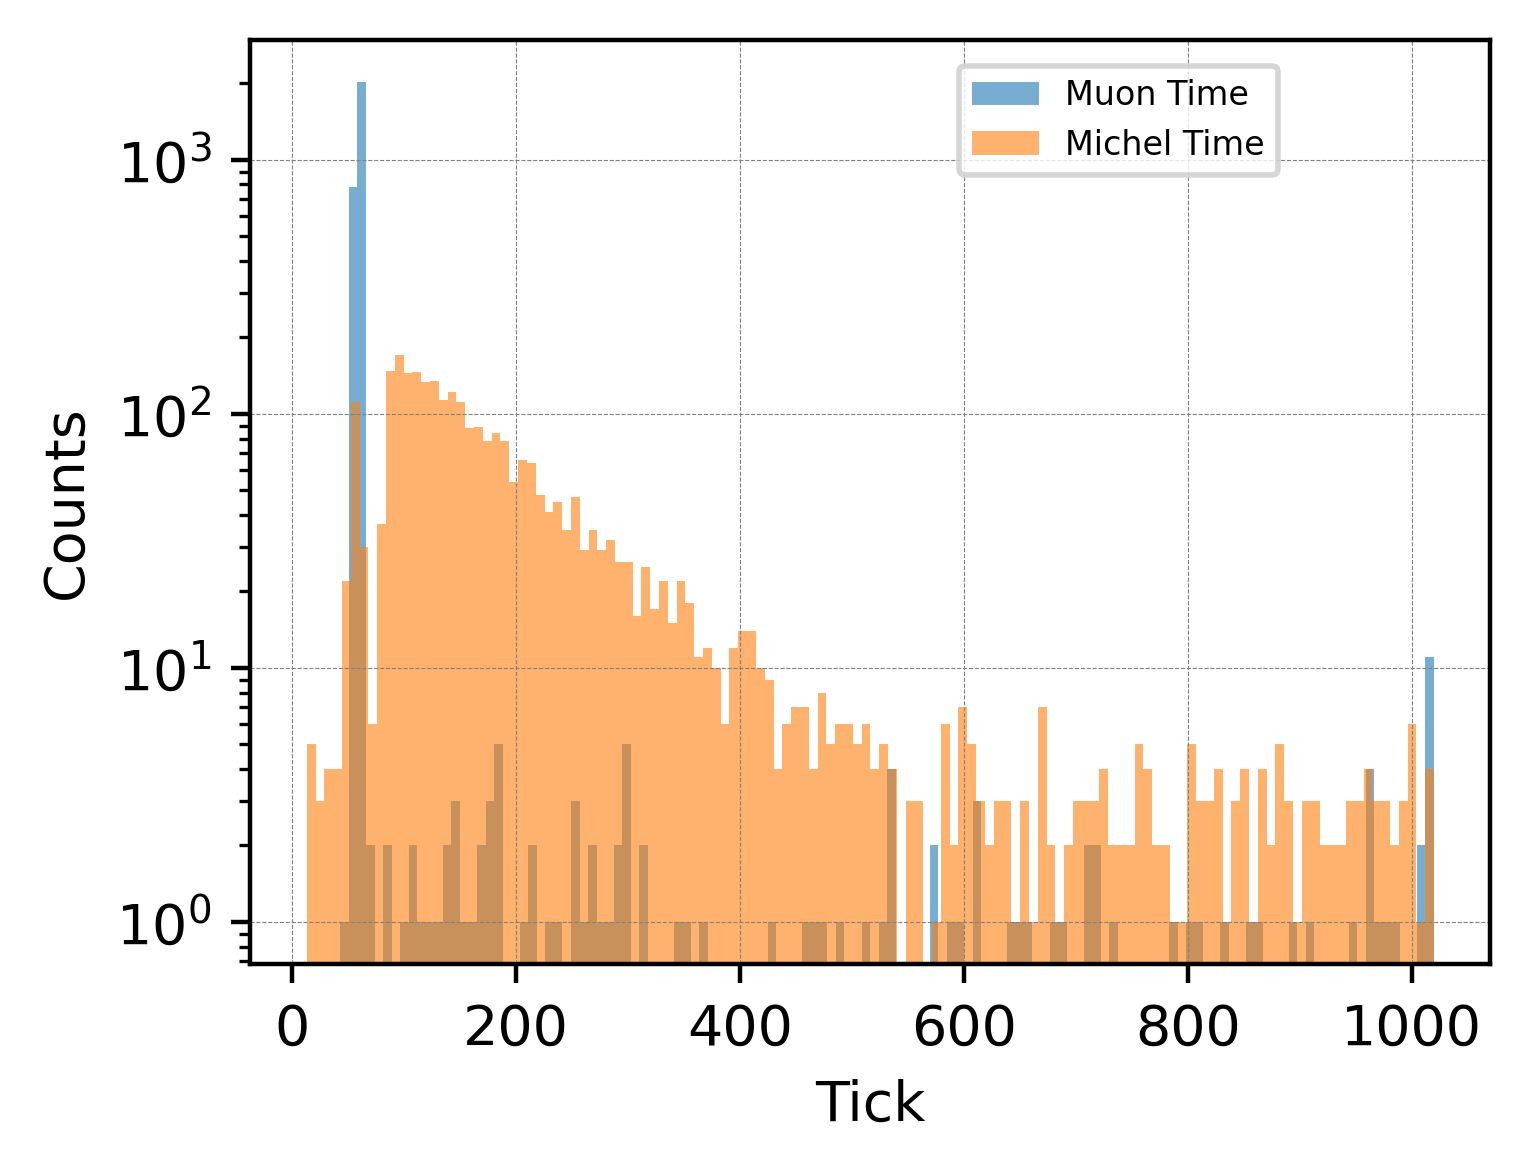


Lifetime distribution:
# Initial Candidates [-16000, 16000]:  2922
# Initial Candidates [0, 16000]:  2755 (94.28%)


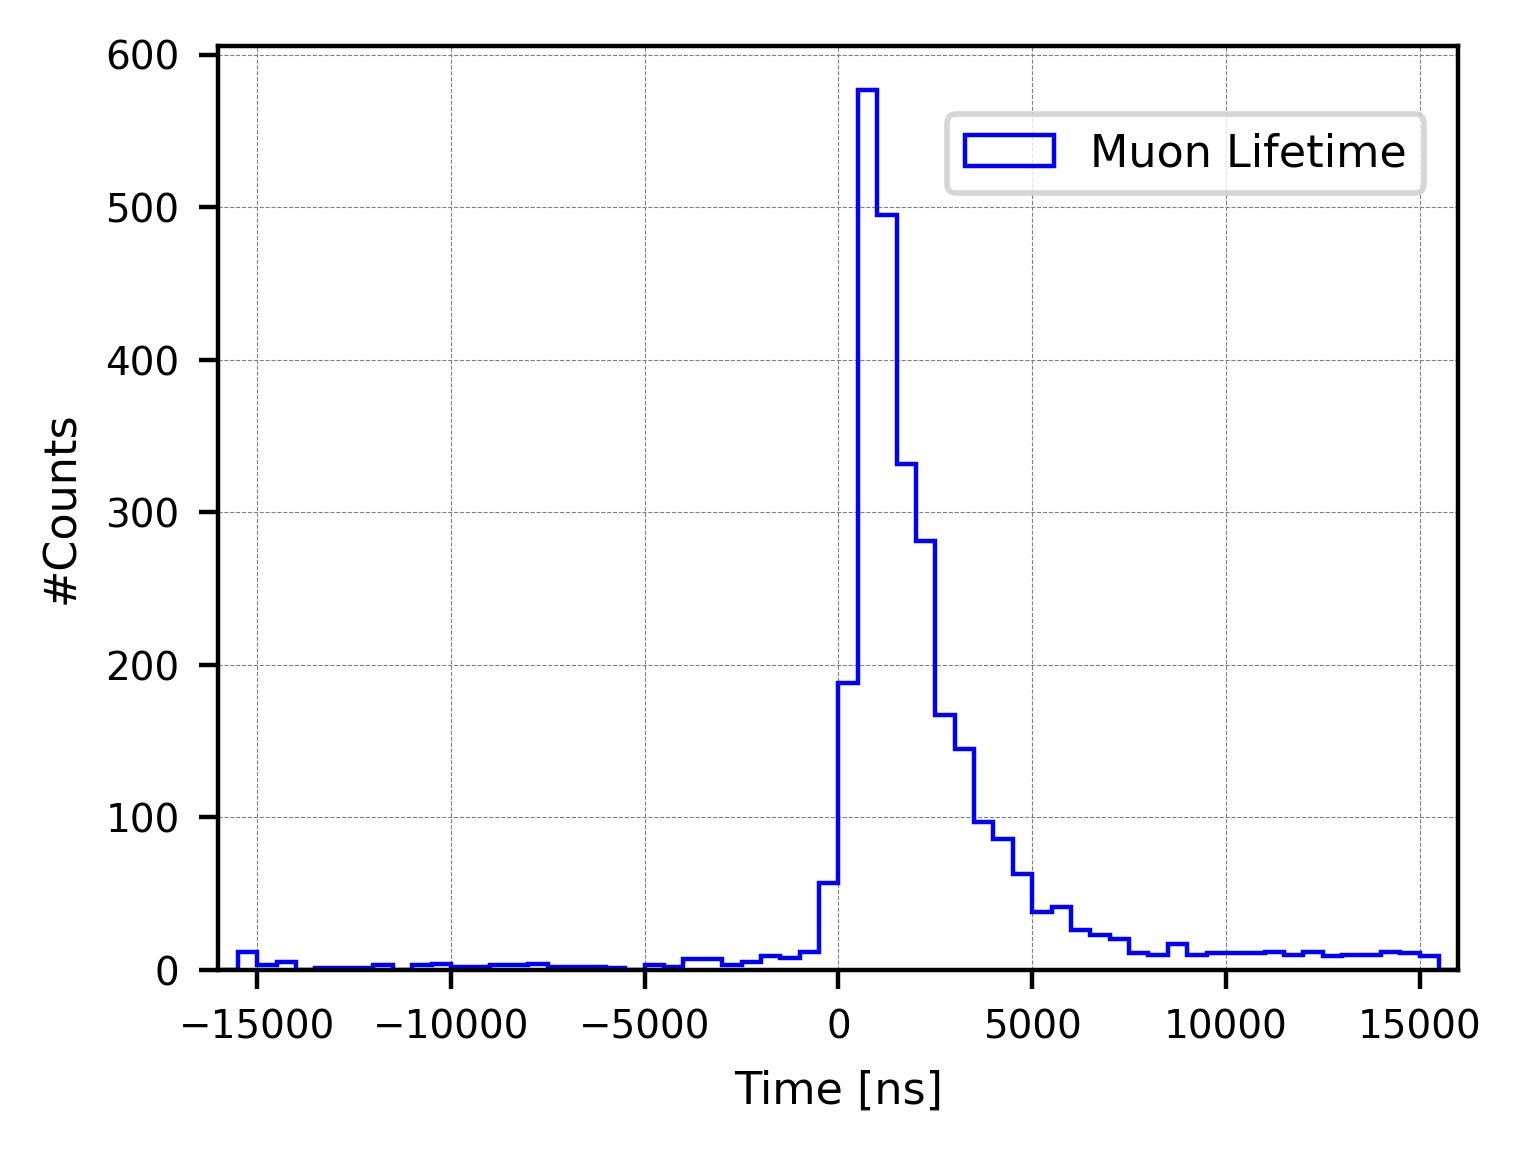

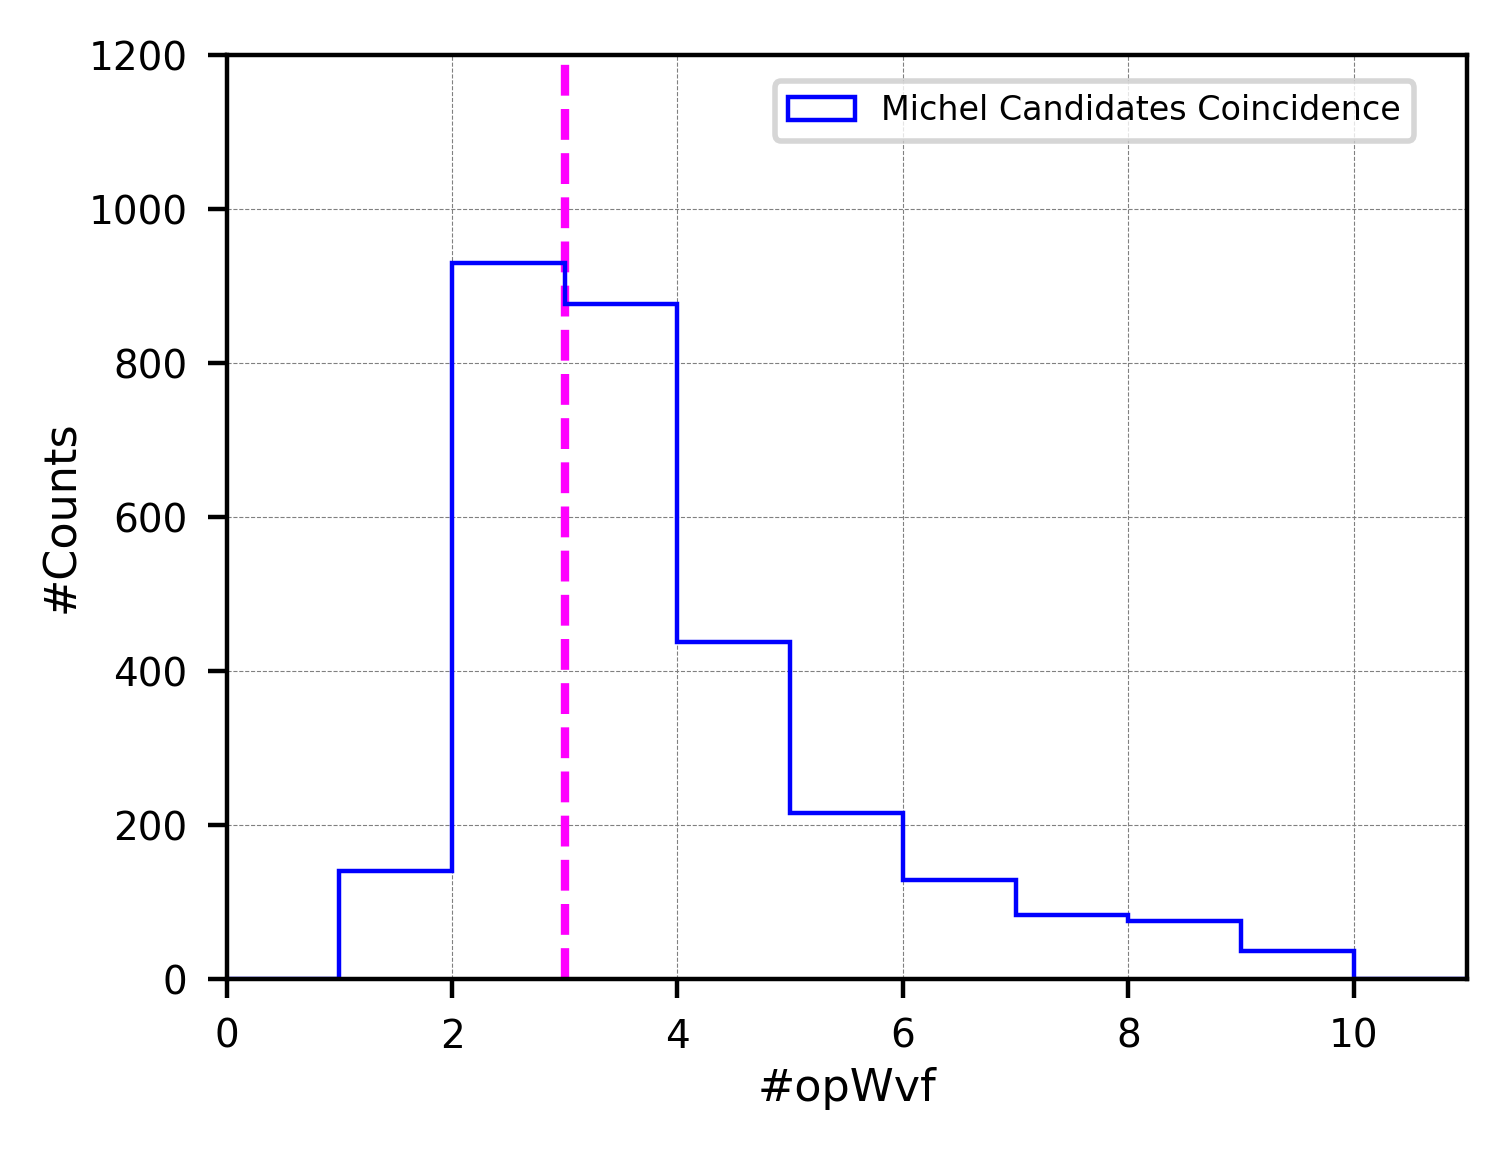

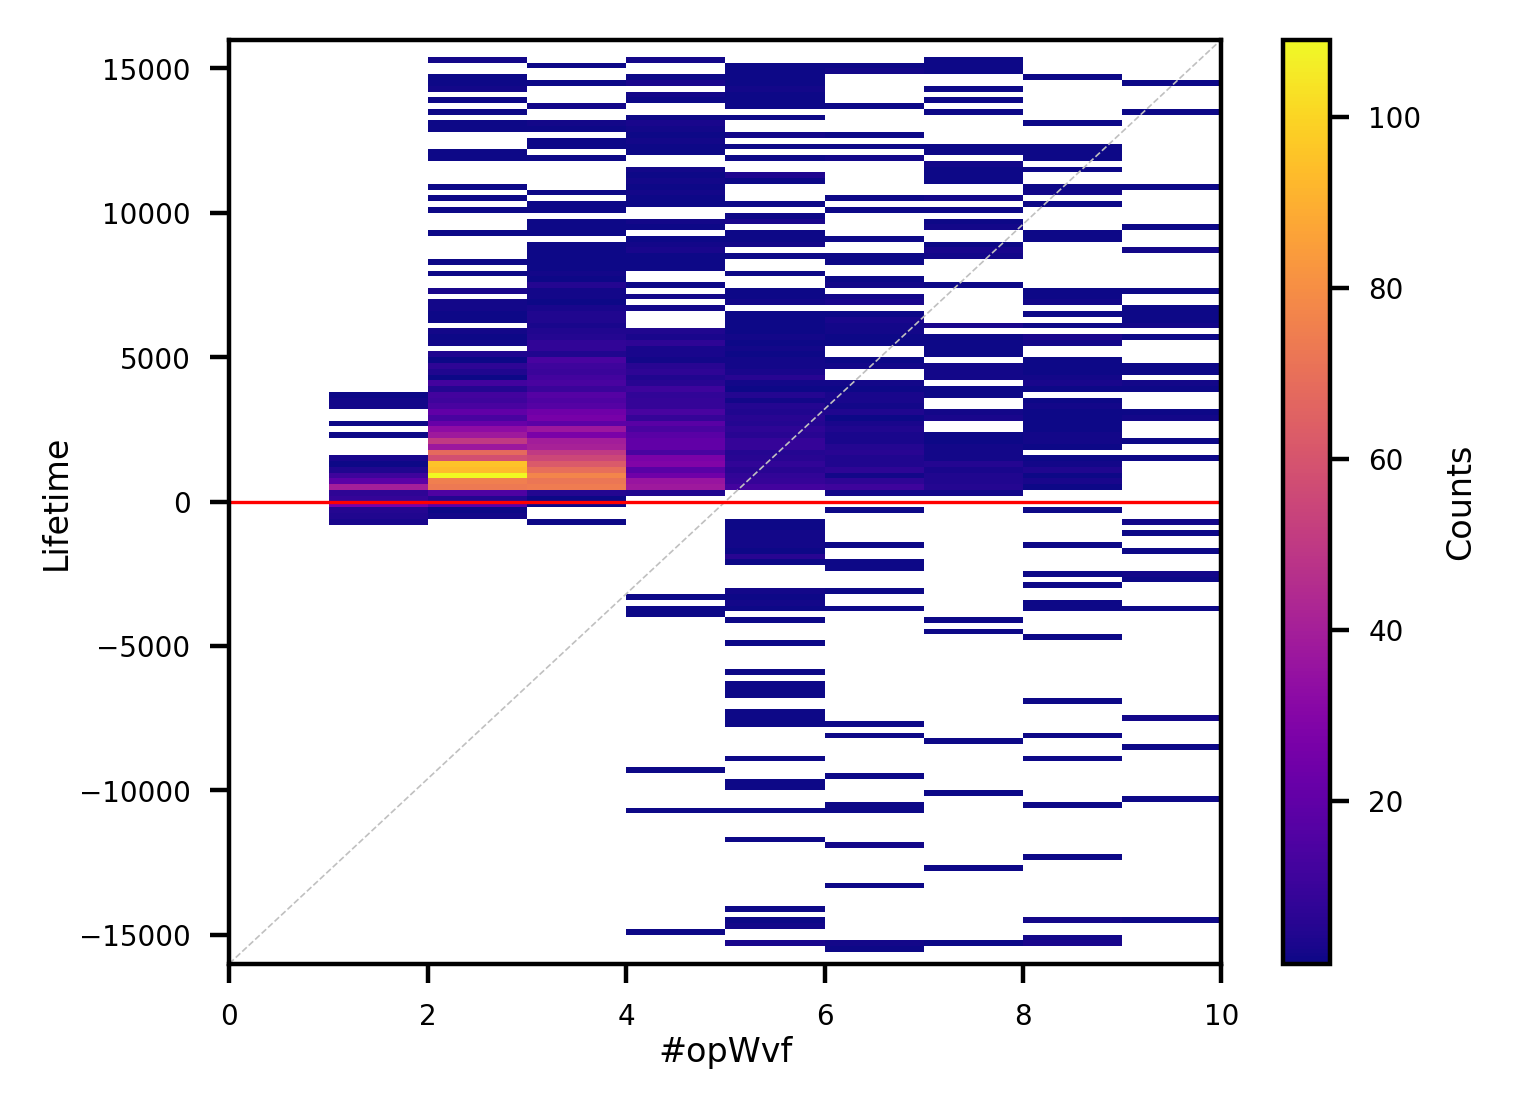

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Plot histograms on the same canvas
plt.hist(peakFinder_muTime, bins=128, alpha=0.6, label='Muon Time')
plt.hist(peakFinder_miTime, bins=128, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
#plt.title('Histogram of muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()








# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
mu_lifetime_ns = [value * 16 for value in mu_lifetime]
print("\nLifetime distribution:")
print("# Initial Candidates [-16000, 16000]: ", len(mu_lifetime_ns))

# Apply test cut
mu_lifetime_ns_test = [val for val in mu_lifetime_ns if 0 < val < 16000]
print("# Initial Candidates [0, 16000]: ", len(mu_lifetime_ns_test), "({:.2f}%)".format(len(mu_lifetime_ns_test)/len(mu_lifetime_ns)*100))

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(-16000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()









# Michel coincidence distribution------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([3, 3], [0, 1200], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(peakFinder_miCoin, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label='Michel Candidates Coincidence')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

plt.xlim(0, 11)
plt.ylim(0, 1200)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






#Lifetime vs opWvf (Original)===============================================

plt.figure(figsize=(4,3),dpi=400)

#y=x---
plt.plot([0, 10], [-16000, 16000], color="silver", linewidth=0.3, linestyle='--')
plt.plot([0, 10], [0, 0], color="red", linewidth=0.6, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(peakFinder_miCoin, mu_lifetime_ns, bins=(10, 160), range=[[0, 10], [-16000, 16000]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(0, 10)
plt.ylim(-16000, 16000)
plt.xlabel('#opWvf', labelpad=1, fontsize=6)
plt.ylabel('Lifetime', labelpad=1, fontsize=6)
#plt.title('After Space Cut', fontsize=7)
plt.tick_params(labelsize=5)




Keep #coincidence >=3:
# Purified Candidates [-16000, 16000]:  1852
# Purified Candidates [0, 16000]:  1746
# Purified Candidates [500, 16000]:  1746

Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 321 ± 17.9
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 270 ± 16.4
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 198 ± 14.1
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 172 ± 13.1
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 117 ± 10.8
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 101 ± 10.0
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 74 ± 8.6
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 70 ± 8.4
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 54 ± 7.3
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 32 ± 5.7
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 38 ± 6.2
Bin 12: Range = [6000, 6500) | 

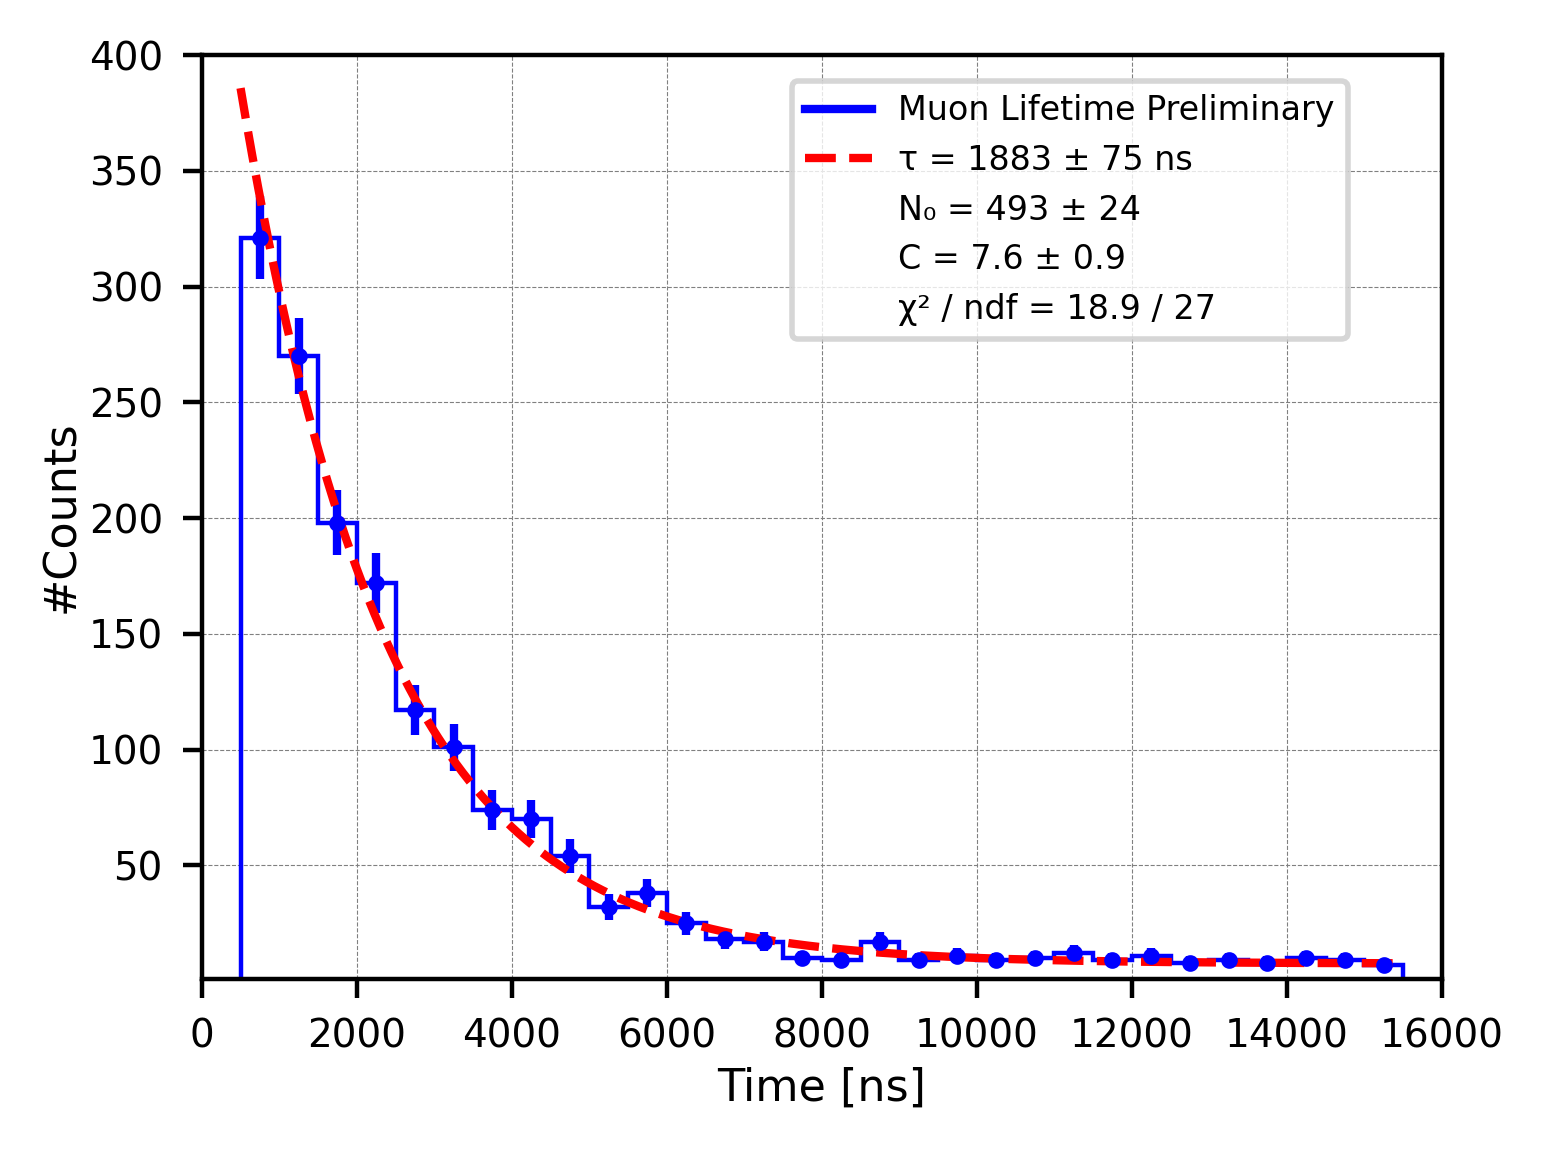

In [20]:
#Remove candidates with coincidence <3-----------------------------------------------
mu_lifetime_ns_purified = []

for i in range(0, len(peakFinder_miCoin)):
    coin = peakFinder_miCoin[i]
    time = mu_lifetime_ns[i]

    if coin >= 3:
        mu_lifetime_ns_purified.append(time)
    
print("Keep #coincidence >=3:")    
print("# Purified Candidates [-16000, 16000]: ", len(mu_lifetime_ns_purified))

#Test-------
mu_lifetime_ns_purified_00 = [val for val in mu_lifetime_ns_purified if 0 <= val <= 16000]
mu_lifetime_ns_purified_500 = [val for val in mu_lifetime_ns_purified if 0 <= val <= 16000]
print("# Purified Candidates [0, 16000]: ", len(mu_lifetime_ns_purified_00))
print("# Purified Candidates [500, 16000]: ", len(mu_lifetime_ns_purified_500))










#Plot---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_purified_500, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8,
                                 label='Muon Lifetime Preliminary')

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)

# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
expected = exp_func(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)  # Avoid division by zero
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Print goodness-of-fit summary
print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Histogram handle
hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()



<br />
<br />

#### Maximum Likelihood Estimation:


Maximum Likelihood Estimation:==================

[MLE Fit] Fitted parameters (Poisson likelihood):
N0 = 488.13
tau0 = 1907.47 ns
C = 7.89

[MLE Fit] Parameter uncertainties:
N0 uncertainty = 24.06
tau0 uncertainty = 74.05 ns
C uncertainty = 0.86

[Goodness of Fit] χ² / ndf = 19.5 / 27 = 0.72
Bin 0 (center=750.00): n = 321.00; expected = 337.33; residual = -16.33; residual/yerr = -0.91
Bin 1 (center=1250.00): n = 270.00; expected = 261.37; residual = 8.63; residual/yerr = 0.53
Bin 2 (center=1750.00): n = 198.00; expected = 202.92; residual = -4.92; residual/yerr = -0.35
Bin 3 (center=2250.00): n = 172.00; expected = 157.95; residual = 14.05; residual/yerr = 1.07
Bin 4 (center=2750.00): n = 117.00; expected = 123.35; residual = -6.35; residual/yerr = -0.59
Bin 5 (center=3250.00): n = 101.00; expected = 96.73; residual = 4.27; residual/yerr = 0.43
Bin 6 (center=3750.00): n = 74.00; expected = 76.24; residual = -2.24; residual/yerr = -0.26
Bin 7 (center=4250.00): n = 70.00; expected = 60

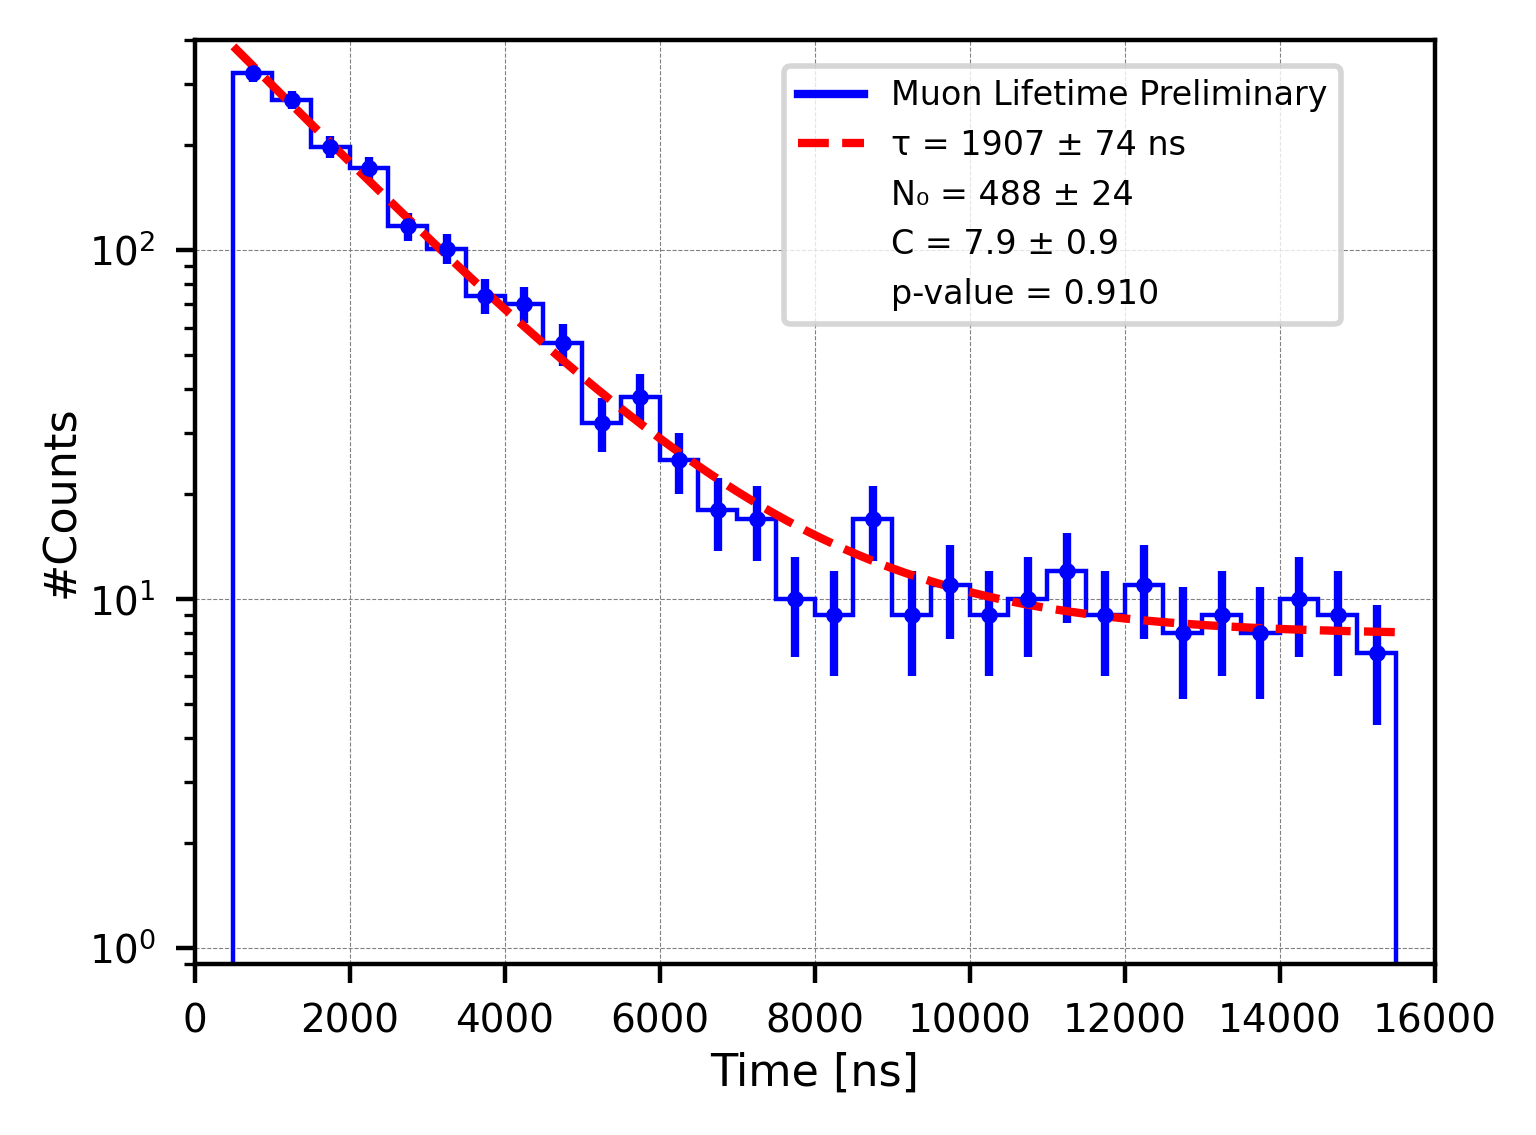


Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 321 ± 17.9
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 270 ± 16.4
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 198 ± 14.1
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 172 ± 13.1
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 117 ± 10.8
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 101 ± 10.0
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 74 ± 8.6
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 70 ± 8.4
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 54 ± 7.3
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 32 ± 5.7
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 38 ± 6.2
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 25 ± 5.0
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 18 ± 4.2
Bin 14: Range = [7000, 7500) | Center = 7250 ns | Entries = 17 ± 4.1
Bin 15: Range =

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln
import numdifftools as nd  # For estimating the Hessian matrix
from scipy.stats import chi2 as chi2_dist

# Your histogram data: replace this with your actual data
# mu_lifetime_ns_purified_test = ...

# Plot setup
plt.figure(figsize=(4, 3), dpi=400)

print("\nMaximum Likelihood Estimation:==================")

# Histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create histogram
n, bin_edges, patches = plt.hist(mu_lifetime_ns_purified_500, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8,
                                 label='Muon Lifetime Preliminary')

# Bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot error bars assuming Poisson errors
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)
plt.errorbar(bin_centers, n, yerr=yerr_plot, fmt='o', color='blue', markersize=2)

# Exponential function to fit
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Negative log-likelihood function for Poisson statistics
def neg_log_likelihood(params, t, counts):
    N0, tau0, C = params
    mu = exp_func(t, N0, tau0, C)
    mu = np.clip(mu, 1e-10, None)  # prevent log(0) and negative values
    log_likelihood = np.sum(counts * np.log(mu) - mu - gammaln(counts + 1))
    return -log_likelihood

# Initial guess for parameters
initial_guess = [max(n), 1000, 1]

# Minimize negative log-likelihood
result = minimize(neg_log_likelihood, initial_guess, args=(bin_centers, n), method='L-BFGS-B')

# Extract fit parameters and uncertainties
if result.success:
    popt = result.x
    print("\n[MLE Fit] Fitted parameters (Poisson likelihood):")
    print("N0 = {:.2f}".format(popt[0]))
    print("tau0 = {:.2f} ns".format(popt[1]))
    print("C = {:.2f}".format(popt[2]))

    # Estimate uncertainties via Hessian
    hessian_fun = nd.Hessian(lambda params: neg_log_likelihood(params, bin_centers, n))
    hessian = hessian_fun(popt)
    pcov = np.linalg.inv(hessian)
    perr = np.sqrt(np.diag(pcov))
    print("\n[MLE Fit] Parameter uncertainties:")
    print("N0 uncertainty = {:.2f}".format(perr[0]))
    print("tau0 uncertainty = {:.2f} ns".format(perr[1]))
    print("C uncertainty = {:.2f}".format(perr[2]))

    # Text for legend
    n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
    tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
    c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'

    # Plot fitted curve
    t_fit = np.linspace(range_min, range_max, 1000)
    fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

    # Calculate residuals and chi^2/ndf for visual goodness-of-fit check
    expected = exp_func(bin_centers, *popt)
    expected = np.clip(expected, 1e-10, None)
    residuals = n - expected
    chi2 = np.sum((residuals / yerr_plot) ** 2)
    ndf = len(n) - len(popt)
    chi2_ndf = chi2 / ndf

    print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

    for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
        print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; residual = {res:.2f}; residual/yerr = {res / err:.2f}")



    # -------------------------------
    # Evaluate goodness-of-fit via Likelihood Ratio Test
    # -------------------------------

    # Log-likelihood for the fitted model:
    mu_fit = exp_func(bin_centers, *popt)
    mu_fit = np.clip(mu_fit, 1e-10, None)
    logL_model = np.sum(n * np.log(mu_fit) - mu_fit - gammaln(n + 1))

    # For the saturated model, we use the observed counts (treating 0*log(0) as 0).
    def safe_nlogn(n_val):
        return np.where(n_val > 0, n_val * np.log(n_val), 0)

    logL_sat = np.sum(safe_nlogn(n) - n - gammaln(n + 1))

    # Compute the likelihood ratio statistic (deviance):
    G2 = 2 * (logL_sat - logL_model)
    print(f"\n[MLE Fit] Likelihood Ratio Test Statistic (G²): {G2:.2f}")

    # Degrees of freedom (number of bins - number of parameters)
    dof = len(n) - len(popt)
    print(f"Degrees of Freedom: {dof}")

    # Calculate p-value based on chi-squared distribution
    p_value = chi2_dist.sf(G2, dof)
    print(f"P-value: {p_value:.4f}")

    # Dummy handles for legend
    dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
    dummy_c = plt.Line2D([], [], color='none', label=c_text)
    dummy_pval = plt.Line2D([], [], color='none', label=f'p-value = {p_value:.3f}')

    # Histogram handle
    hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

    # Plot legend
    plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_pval],
               loc='upper center', bbox_to_anchor=(0.7, 0.99),
               fontsize=7, ncol=1, prop={'size': 6})

else:
    print("❌ Fit failed:", result.message)

# Final plot formatting
plt.xlim(0, 16000)
plt.ylim(0.9, 400)
plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")


<br />
<br />

#### Fitting with double exponential function:

$$
\large
N(t) = N_1 \cdot e^{-t / \tau_1} + N_2 \cdot e^{-t / \tau_2} + C
$$
where $\tau_2 = 2200 ns$

Keep #coincidence >=3:
# Purified Candidates [-16000, 16000]:  1852
# Purified Candidates [0, 16000]:  1746
# Purified Candidates [500, 16000]:  1746

Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 321 ± 17.9
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 270 ± 16.4
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 198 ± 14.1
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 172 ± 13.1
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 117 ± 10.8
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 101 ± 10.0
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 74 ± 8.6
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 70 ± 8.4
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 54 ± 7.3
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 32 ± 5.7
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 38 ± 6.2
Bin 12: Range = [6000, 6500) | 

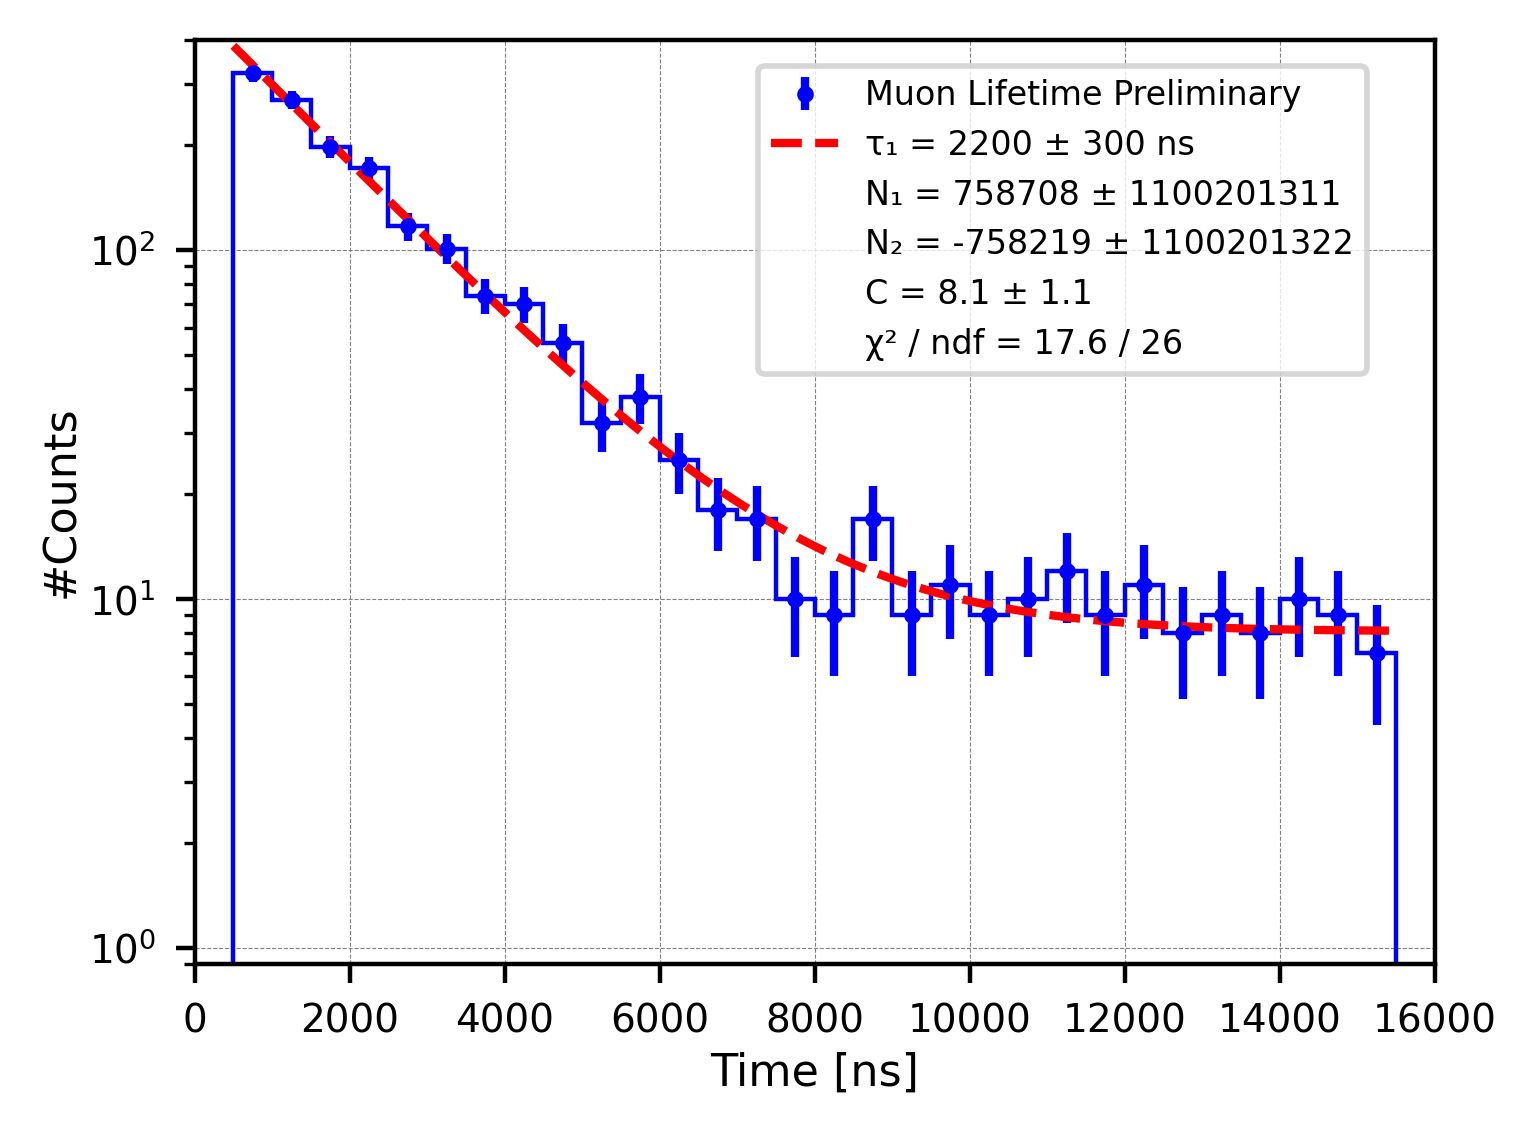

In [19]:
#Remove candidates with coincidence <3-----------------------------------------------
mu_lifetime_ns_purified = []

for i in range(0, len(peakFinder_miCoin)):
    coin = peakFinder_miCoin[i]
    time = mu_lifetime_ns[i]

    if coin >= 3:
        mu_lifetime_ns_purified.append(time)
    
print("Keep #coincidence >=3:")    
print("# Purified Candidates [-16000, 16000]: ", len(mu_lifetime_ns_purified))

#Test-------
mu_lifetime_ns_purified_00 = [val for val in mu_lifetime_ns_purified if 0 <= val <= 16000]
mu_lifetime_ns_purified_500 = [val for val in mu_lifetime_ns_purified if 0 <= val <= 16000]
print("# Purified Candidates [0, 16000]: ", len(mu_lifetime_ns_purified_00))
print("# Purified Candidates [500, 16000]: ", len(mu_lifetime_ns_purified_500))









#Plot---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_purified_500, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8)

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
hist_handle = plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2, label='Muon Lifetime Preliminary')

# Define the double exponential function with fixed tau_2 = 2200 ns
def exp_func_fixed_tau2(t, N1, tau1, N2, C):
    tau2_fixed = 2200  # ns
    return N1 * np.exp(-t / tau1) + N2 * np.exp(-t / tau2_fixed) + C

# Least Squares Method with fixed tau_2-------
# Initial guess: [N1, tau1, N2, C]
popt, pcov = curve_fit(
    exp_func_fixed_tau2, bin_centers, n,
    p0=[max(n)/5, 500, max(n), 10],
    sigma=yerr, absolute_sigma=True,
    maxfev=10000  # increased from default 1000
)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print fitted parameters
print("\nFitted parameters:")
print("N1 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau1 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("N2 = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))
print("C = {:.2f} +/- {:.2f}".format(popt[3], perr[3]))

# Calculate expected values and chi-squared
expected = exp_func_fixed_tau2(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
n1_text = f'N₁ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau1_text = f'τ₁ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
n2_text = f'N₂ = {popt[2]:.0f} ± {perr[2]:.0f}'
c_text = f'C = {popt[3]:.1f} ± {perr[3]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func_fixed_tau2(t_fit, *popt), color='red', linestyle='--', label=tau1_text)

# Dummy handles for displaying additional info in the legend
dummy_n1 = plt.Line2D([], [], color='none', label=n1_text)
dummy_n2 = plt.Line2D([], [], color='none', label=n2_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Finalize legend
plt.legend(handles=[hist_handle, fit_line, dummy_n1, dummy_n2, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0.9, 400)
plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()
